In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
import statsmodels.formula.api as smf
import statsmodels.api as sm
from BIGFAM import obj2, tools, frreg
import importlib

In [21]:
source = "GS" # UKB, GS
pheno = "ratio" # FEV1__FVC_ratio_Z-score, "ratio"

# Step 1. Relative info

In [22]:
# parameters
info_fn = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{source}/relative_information/relatives.formatted.info"

In [23]:
# relative information format
df_pair = pd.read_csv(info_fn, sep='\t')

In [24]:
# flip and concat the relatives
# unique id set
df_pair = tools.remove_duplicate_relpair(df_pair, ["volid", "relid"])

# flip and concat volid and relid
colns_to_flip = {"volid": "relid", 
                    "volage": "relage", 
                    "volsex": "relsex"}
df_pair = (tools.flip_and_concat(df_pair.copy(), colns_to_flip)
           .dropna()
           .reset_index(drop=True))

# Step 2. Load phenotype

In [25]:
pheno_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{source}/phenotype"

In [26]:
# load phenotype
pheno_fn = f"{pheno_path}/{pheno}.phen"
df_pheno = (pd.read_csv(pheno_fn, sep="\t")
            .dropna()
            .reset_index(drop=True))

In [27]:
# standardize phenotype
df_pheno["pheno"] = frreg.std_col(df_pheno["pheno"])

In [28]:
# remove outlier
less = -3 * np.std(df_pheno["pheno"])
more = 3 * np.std(df_pheno["pheno"])
outliers = (df_pheno["pheno"] < less) | (df_pheno["pheno"] > more)
sum(outliers)

256

In [29]:
df_pheno = df_pheno[~outliers].copy().reset_index(drop=True)
# df_pheno["pheno"] = frreg.std_col(df_pheno["pheno"])
df_pheno

,eid,pheno
0,90826,1.200180
1,32660,0.590106
2,90831,-1.148829
3,68776,0.468858
4,82851,0.726583
...,...,...
16558,46093,0.061226
16559,71541,-0.925084
16560,97675,0.027494
16561,36172,-0.890556


# Step 3. Merge info & pheno

In [30]:
df_mrg = frreg.merge_pheno_info(df_pheno, df_pair)

In [43]:
# std by sex
for indiv in ["vol", "rel"]:
    indiv_M = (df_mrg[f"{indiv}sex"] == "M")
    indiv_F = (df_mrg[f"{indiv}sex"] == "F")
    
    indivpheno_M = df_mrg.loc[indiv_M, f"{indiv}pheno"]
    indivpheno_F = df_mrg.loc[indiv_F, f"{indiv}pheno"]
    
    df_mrg.loc[indiv_M, f"{indiv}pheno"] = (indivpheno_M - np.mean(indivpheno_M)) / np.std(indivpheno_M)
    df_mrg.loc[indiv_F, f"{indiv}pheno"] = (indivpheno_F - np.mean(indivpheno_F)) / np.std(indivpheno_F)

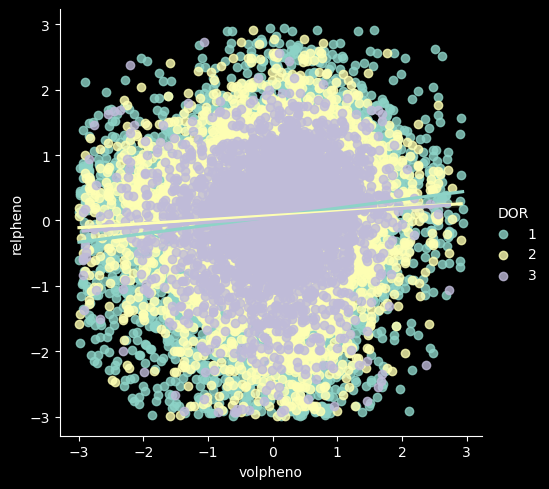

In [32]:
sns.lmplot(
    data=df_mrg,
    x="volpheno",
    y="relpheno",
    hue="DOR"
)

# Step 4. FRreg

In [44]:
# FR-reg (DOR level)
df_dor = pd.DataFrame(
    columns=["DOR", "relationship", "sex_type", "Erx", "slope", "se", "p", "n"]
)

for d in sorted(df_mrg["DOR"].unique()):
    df_tmp = df_mrg[df_mrg["DOR"] == d].copy()
    
    # regression
    formula = "volpheno ~ 0 + relpheno"
    ll = smf.ols(formula, data=df_tmp).fit()
    
    
    # save results
    Erx = df_mrg[df_mrg["DOR"] == d]["Erx"].mean()
    df_dor.loc[len(df_dor)] = [d, 
                                   "all", 
                                   "all", 
                                   Erx,
                                   ll.params[0], 
                                   ll.bse[0], 
                                   ll.pvalues[0], 
                                   ll.nobs]

df_dor

,DOR,relationship,sex_type,Erx,slope,se,p,n
0,1,all,all,0.517043,0.130135,0.006187,2.116086e-97,25684.0
1,2,all,all,0.284027,0.062047,0.009732,1.902315e-10,10518.0
2,3,all,all,0.147081,0.070969,0.016572,1.895710e-05,3624.0


# Step 5. Find X

## Step 5.1 relationship level

In [45]:
# FR-reg (relationship level)
df_rel = pd.DataFrame(
    columns=["DOR", "relationship", "sex_type", "Erx", "slope", "se", "p", "n"]
)

for d in sorted(df_mrg["DOR"].unique()):
    df_tmp = df_mrg[df_mrg["DOR"] == d].copy()
    
    for rel in sorted(df_tmp["relationship"].unique()):
        df_ttmp = df_tmp[df_tmp["relationship"] == rel].copy()
        df_ttmp["sex_type"] = frreg.get_sextype(df_ttmp)
        sex_type = df_ttmp["sex_type"].unique()[0]
        Erx = df_ttmp["Erx"].unique()[0]
        
        if len(df_ttmp) < 100:
            # print(rel, len(df_ttmp))
            continue
        
        # regression
        formula = "volpheno ~ 0 + relpheno"
        ll = smf.ols(formula, data=df_ttmp).fit()
        
        # save results
        df_rel.loc[len(df_rel)] = [d, rel, sex_type, Erx,
                                    ll.params[0], 
                                    ll.bse[0], 
                                    ll.pvalues[0], 
                                    ll.nobs]

df_rel.groupby(["DOR"]).size()

DOR
1     7
2    20
3    16
dtype: int64

In [46]:
df_tl = obj2._regressOutMean(df_rel, bin=["DOR"])

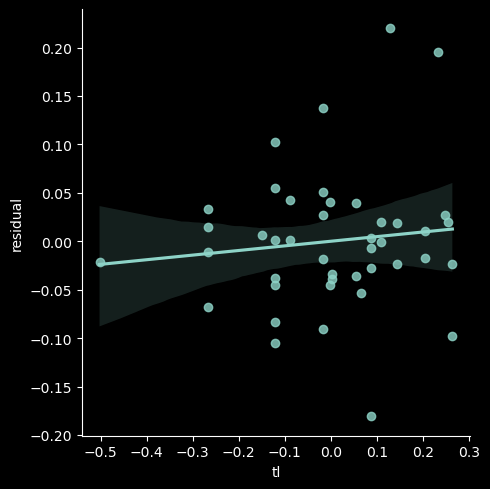

In [47]:
# no L2
sns.lmplot(
    data=df_tl,
    x="tl",
    y="residual",
    # hue="DOR"
)

In [48]:
formula = "residual ~ tl"
smf.ols(formula, data=df_tl).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               residual   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.5191
Date:                Wed, 01 May 2024   Prob (F-statistic):              0.475
Time:                        17:01:49   Log-Likelihood:                 52.762
No. Observations:                  43   AIC:                            -101.5
Df Residuals:                      41   BIC:                            -98.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.821e-17      0.011  -1.64e-15      1.000      -0.022       0.022
tl             0.0477      0.066      0.720      0.475      -0.086       0.181
==============================================================================
Omnibus:                        8.594   Durbin-Watson:                   2.394
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                9.460
Skew:                           0.649   Prob(JB):                      0.00883
Kurtosis:                       4.896   Cond. No.                         5.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
model = sm.OLS(df_tl["residual"], df_tl["tl"])

eta = np.mean((2**df_dor["DOR"]) * df_dor["slope"])
print("eta : ", np.round(eta, 3))
print("------------------------------")

for pwr in np.arange(-4, 5):
    alpha = eta**pwr
    results = model.fit_regularized(method="elastic_net", 
                                    alpha=alpha, 
                                    L1_wt=0.0)
    print(pwr, "|", np.round(alpha, 2), "|", np.round(results.params[0], 4))

eta :  0.359
------------------------------
-4 | 60.38 | 0.0
-3 | 21.66 | 0.0001
-2 | 7.77 | 0.0002
-1 | 2.79 | 0.0005
0 | 1.0 | 0.0013
1 | 0.36 | 0.0035
2 | 0.13 | 0.0085
3 | 0.05 | 0.018
4 | 0.02 | 0.03


# Step 6. Find X in males and females

## Step 6.1 Male따로, Female 따로

In [266]:
df_tl_male = obj2._regressOutMean(df_rel[df_rel["sex_type"] == "MM"].copy(),
                                  bin=["DOR"])
df_tl_female = obj2._regressOutMean(df_rel[df_rel["sex_type"] == "FF"].copy(),
                                    bin=["DOR"])

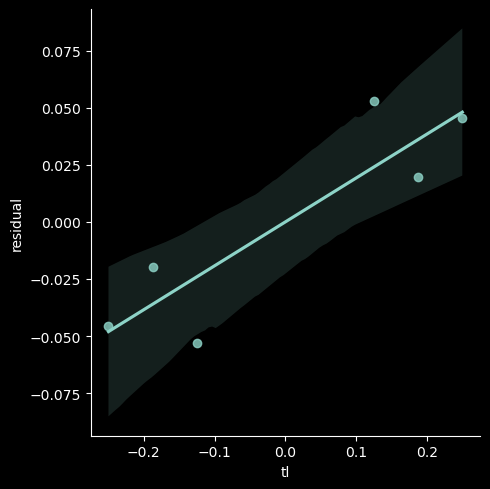

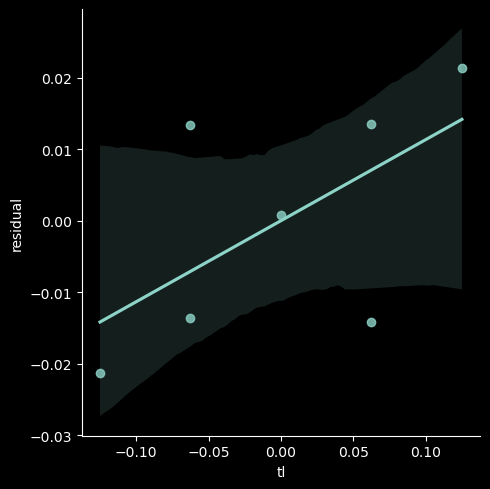

In [252]:
# no L2
sns.lmplot(
    data=df_tl_male,
    x="tl",
    y="residual",
    # hue="DOR"
)

sns.lmplot(
    data=df_tl_female,
    x="tl",
    y="residual",
    # hue="DOR"
)

In [253]:
formula = "residual ~ tl"
smf.ols(formula, data=df_tl_female).fit().summary()

/home/jerrylee/miniconda3/envs/BIGFAM/lib/python3.9/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               residual   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     2.835
Date:                Wed, 01 May 2024   Prob (F-statistic):              0.153
Time:                        16:50:14   Log-Likelihood:                 20.836
No. Observations:                   7   AIC:                            -37.67
Df Residuals:                       5   BIC:                            -37.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.946e-17      0.006   7.16e-15      1.000      -0.014       0.014
tl             0.1135      0.067      1.684      0.153      -0.060       0.287
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   3.091
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.104
Skew:                          -0.081   Prob(JB):                        0.949
Kurtosis:                       2.425   Cond. No.                         12.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [254]:
formula = "residual ~ tl"
smf.ols(formula, data=df_tl_male).fit().summary()

/home/jerrylee/miniconda3/envs/BIGFAM/lib/python3.9/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               residual   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     14.99
Date:                Wed, 01 May 2024   Prob (F-statistic):             0.0180
Time:                        16:50:17   Log-Likelihood:                 15.171
No. Observations:                   6   AIC:                            -26.34
Df Residuals:                       4   BIC:                            -26.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.898e-17      0.010   6.11e-15      1.000      -0.027       0.027
tl             0.1923      0.050      3.871      0.018       0.054       0.330
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.394
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.305
Skew:                          -0.000   Prob(JB):                        0.859
Kurtosis:                       1.896   Cond. No.                         5.15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

male, female 따로 하면.. std도 크게 나오고... 안맞음

## Step 6.2 Male, Female 같이

### Step 6.2.1 relationship-level

원래 방식대로, DOR내의 sex-type별로 다양한 relationship들에 대해서 regress out mean

In [50]:
df_tl_rel = obj2._regressOutMean(df_rel, bin=["DOR", "sex_type"])
df_tl_rel

,DOR,relationship,sex_type,Erx,slope,se,p,n,eta,residual,tl
0,1,DF,FM,0.707107,0.114876,0.018256,3.582476e-10,2962.0,0.264639,-0.017444,0.117851
1,1,DM,FF,0.500000,0.086824,0.014420,1.861662e-09,4774.0,0.245630,-0.035991,-0.125000
2,1,DS,FF,0.750000,0.158806,0.014687,6.381938e-27,4520.0,0.245630,0.035991,0.125000
3,1,SB,MM,0.500000,0.172322,0.021389,1.294534e-15,2122.0,0.282932,0.030856,0.250000
4,1,SF,MM,0.000000,0.110610,0.020174,4.619776e-08,2428.0,0.282932,-0.030856,-0.250000
5,1,SM,FM,0.707107,0.143108,0.016931,4.167884e-17,3418.0,0.264639,0.010788,0.117851
6,1,SS_DB,FM,0.353553,0.138976,0.013403,5.851308e-25,5460.0,0.264639,0.006656,-0.235702
7,2,DF_SB,FM,0.353553,0.037409,0.056665,5.096320e-01,312.0,0.121829,0.006951,0.070711
8,2,DF_SS_DB,FF,0.250000,0.202095,0.043156,3.623027e-06,516.0,0.421372,0.096752,-0.083333
9,2,DM_DM,FF,0.250000,0.046079,0.047038,3.278069e-01,452.0,0.421372,-0.059264,-0.083333


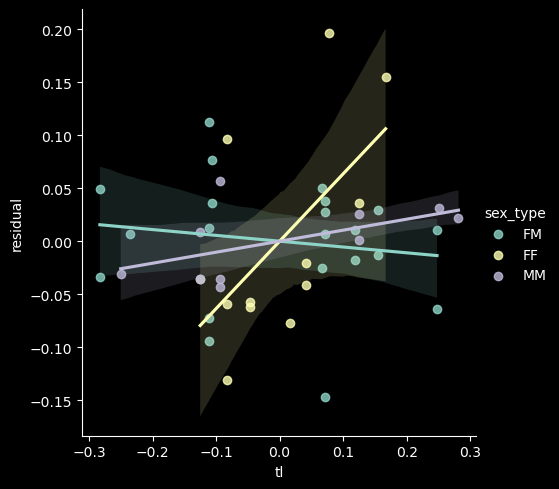

In [51]:
sns.lmplot(
    data=df_tl_rel,
    x="tl",
    y="residual",
    hue="sex_type"
)

In [52]:
eta = np.mean((2**df_dor["DOR"]) * df_dor["slope"])
print("eta : ", np.round(eta, 3))
print("------------------------------")

for pwr in np.arange(-4, 5):
    alpha = eta**pwr
    results = obj2._optToFindXmXf(df_tl_rel, alpha)
    print(pwr, "|", np.round(alpha, 2), "|", np.round(results.x, 4))

eta :  0.359
------------------------------
-4 | 60.38 | [0.0005 0.001 ]
-3 | 21.66 | [0.0014 0.0027]
-2 | 7.77 | [0.0038 0.0076]
-1 | 2.79 | [0.0099 0.0208]
0 | 1.0 | [0.0233 0.0548]
1 | 0.36 | [0.0467 0.1321]
2 | 0.13 | [0.0776 0.2687]
3 | 0.05 | [0.0898 0.4266]
4 | 0.02 | [0.0984 0.5408]


둘이 안나눠지고, 같이 움직임

### Step 6.2.2 Erx level

In [117]:
# FR-reg (sex_type & Erx level)
df_Erx = pd.DataFrame(
    columns=["DOR", "relationship", "sex_type", "Erx", "slope", "se", "p", "n"]
)

def get_unique_values(vals, tol=1e-8):
    uniq_vals = []
    
    for val in np.unique(vals):
        if len(uniq_vals) == 0:
            uniq_vals += [val]
            continue
    
        add_val = True
        for v in uniq_vals:
            lower = v - tol
            upper = v + tol
            if (val > lower) & (val < upper):
                add_val = False
            else:
                pass
                
        if add_val:
            uniq_vals += [val]
    
    return uniq_vals

df_frreg_erx = pd.DataFrame(
    columns=["DOR", "relationship", "sex_type", "Erx", "slope", "se", "p", "n"]
)

tol = 1e-6
for d in sorted(df_mrg["DOR"].unique()):
    df_tmp = df_mrg[df_mrg["DOR"] == d].copy()
    df_tmp["sex_type"] = frreg.get_sextype(df_tmp)
    
    for st in df_tmp["sex_type"].unique():
        df_ttmp = df_tmp[df_tmp["sex_type"] == st]
        Erxs = get_unique_values(df_ttmp["Erx"], tol=tol)
        
        # FR-reg for each Erx
        for erx in Erxs:
            df_tttmp = df_ttmp[(df_ttmp["Erx"] > erx-tol) & (df_ttmp["Erx"] < erx+tol)].copy()
            
            if len(df_tttmp) < 100:
                continue
            
            # regression
            formula = "volpheno ~ 0 + relpheno"
            ll = smf.ols(formula, data=df_tttmp).fit()
            
            # save results
            df_frreg_erx.loc[len(df_frreg_erx)] = [d, 
                                       "+".join(df_tttmp["relationship"].unique()),
                                       st,
                                        erx,
                                        ll.params[0], 
                                        ll.bse[0], 
                                        ll.pvalues[0], 
                                        ll.nobs]

In [116]:
df_frreg_erx

,DOR,relationship,sex_type,Erx,slope,se,p,n
0,1,DM,FF,0.500000,0.093799,0.014411,8.344408e-11,4774.0
1,1,DS,FF,0.750000,0.165062,0.014672,5.581809e-29,4520.0
2,1,SS_DB,FM,0.353553,0.142601,0.013396,3.323488e-26,5460.0
3,1,SM+DF,FM,0.707107,0.137229,0.012402,3.344380e-28,6380.0
4,1,SF,MM,0.000000,0.116466,0.020160,8.580639e-09,2428.0
5,1,SB,MM,0.500000,0.177113,0.021370,2.019286e-16,2122.0
6,2,SF_SS_DB+SF_SM+SS_DB_SF+SF_DF+SM_SF+DF_SF,FM,0.000000,0.069565,0.031038,2.522054e-02,1034.0
7,2,DM_SS_DB+SS_DB_DM,FM,0.176777,0.101377,0.028518,3.926300e-04,1218.0
8,2,DF_SB+SB_DF+DM_SM+DM_DF+SM_DM+DF_DM,FM,0.353553,0.011022,0.029474,7.084913e-01,1152.0
9,2,SM_DS+DS_SM,FM,0.530330,0.012124,0.025673,6.368121e-01,1518.0


In [119]:
df_tl_erx = obj2._regressOutMean(df_frreg_erx, bin=["DOR", "sex_type"])
df_tl_erx

,DOR,relationship,sex_type,Erx,slope,se,p,n,eta,residual,tl
0,1,DM,FF,0.500000,0.093799,0.014411,8.344408e-11,4774.0,0.258861,-0.035632,-1.250000e-01
1,1,DS,FF,0.750000,0.165062,0.014672,5.581809e-29,4520.0,0.258861,0.035632,1.250000e-01
2,1,SS_DB,FM,0.353553,0.142601,0.013396,3.323488e-26,5460.0,0.279831,0.002686,-1.767767e-01
3,1,SM+DF,FM,0.707107,0.137229,0.012402,3.344380e-28,6380.0,0.279831,-0.002686,1.767767e-01
4,1,SF,MM,0.000000,0.116466,0.020160,8.580639e-09,2428.0,0.293579,-0.030324,-2.500000e-01
5,1,SB,MM,0.500000,0.177113,0.021370,2.019286e-16,2122.0,0.293579,0.030324,2.500000e-01
6,2,SF_SS_DB+SF_SM+SS_DB_SF+SF_DF+SM_SF+DF_SF,FM,0.000000,0.069565,0.031038,2.522054e-02,1034.0,0.194088,0.021043,-2.651650e-01
7,2,DM_SS_DB+SS_DB_DM,FM,0.176777,0.101377,0.028518,3.926300e-04,1218.0,0.194088,0.052855,-8.838835e-02
8,2,DF_SB+SB_DF+DM_SM+DM_DF+SM_DM+DF_DM,FM,0.353553,0.011022,0.029474,7.084913e-01,1152.0,0.194088,-0.037500,8.838835e-02
9,2,SM_DS+DS_SM,FM,0.530330,0.012124,0.025673,6.368121e-01,1518.0,0.194088,-0.036398,2.651650e-01


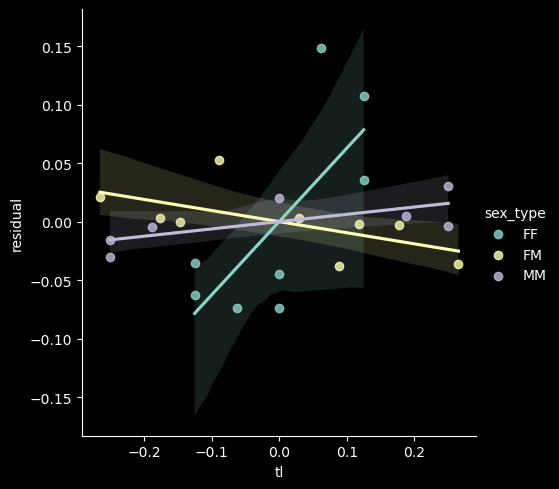

In [120]:
sns.lmplot(
    data=df_tl_erx,
    x="tl",
    y="residual",
    hue="sex_type"
)

In [124]:
eta = np.mean((2**df_dor["DOR"]) * df_dor["slope"])
print("eta : ", np.round(eta, 3))
print("------------------------------")

for pwr in np.arange(-4, 3):
    alpha = eta**pwr
    results = obj2._optToFindXmXf(df_tl_erx, alpha)
    print(pwr, "|", np.round(alpha, 2), "|", np.round(results.x, 4))

eta :  0.377
------------------------------
-4 | 49.31 | [0. 0.]
-3 | 18.61 | [0. 0.]
-2 | 7.02 | [0. 0.]
-1 | 2.65 | [0. 0.]
0 | 1.0 | [0. 0.]
1 | 0.38 | [0.0025 0.0025]
2 | 0.14 | [0.0072 0.0072]
